# TerraMind v1.5 Multicodebook Generation Test

This notebook demonstrates:
1. Loading data from TerraMesh v1.5 zarr files
2. Tokenizer reconstruction with multicodebook (128 codebooks)
3. Full multimodal generation using TerraMind v1.5 checkpoint

## Setup

In [1]:
import sys
import rioxarray as rxr
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Add paths
sys.path.insert(0, '/Users/jja/Documents/02_EOFM/TerraMind-Pretraining')
sys.path.insert(0, '/Users/jja/Documents/02_EOFM/terratorch')

In [2]:
from terratorch.models.backbones.terramind.model.terramind_register import v1_pretraining_mean, v1_pretraining_std
from terramind.data.terramesh import build_terramesh_dataset
from plotting_utils import plot_modality
from terramind.vq import get_image_tokenizer
from terramind.vq.tokenizer_register import (
    terramind_v1_5_tokenizer_lulc,
    terramind_v1_5_tokenizer_s1rtc,
    terramind_v1_5_tokenizer_s2l2a,
    terramind_v1_5_tokenizer_dem,
    terramind_v1_5_tokenizer_ndvi,
    terramind_v1_5_tokenizer_s1grd,
    terramind_v1_5_tokenizer_s2l1c,
    terramind_v1_5_tokenizer_s2rgb
)

from terramind.data.terramesh import build_terramesh_dataset
from terratorch.models.backbones.terramind.model.terramind_generation import TerraMindGeneration
from terratorch.models.backbones.terramind.model.terramind_register import tokenizer_dict

INFO:terratorch:Found custom_modules


Huggingface datasets not installed. Please install with `pip install datasets`.


In [3]:
# Device selection
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: {device}")
modalities = ['S2L2A'] # 'S1RTC', 'S1RTC_tokens', "LULC_tokens", , "NDVI", "NDVI_tokens"

Using device: mps


## Some helper functions

In [4]:
def plot_s2_rgb(data, ax=None, title=None):
    """Plot S2 RGB bands (B, G, R = bands 1, 2, 3)"""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    # Extract RGB bands and normalize
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()

    rgb = data[[3, 2, 1], :, :]  # R, G, B
    rgb = np.transpose(rgb, (1, 2, 0))

    # Normalize to 0-1
    rgb = np.clip(rgb / 3000, 0, 1)

    ax.imshow(rgb)
    ax.axis('off')
    if title:
        ax.set_title(title)

    return ax


# Build tokenizer
def load_model(modality, ckpt_path=None):
    if ckpt_path is not None:
        ckpt_path = Path(ckpt_path)
        model, _ = get_image_tokenizer(
            str(ckpt_path.stem),
            tokenizers_root=str(ckpt_path.parent),
            encoder_only=False,
            device=device,
        )
        model.eval()
        model.to(device)
        return model

    model = tokenizer_build[modality](pretrained=True)
    model.eval()
    model.to(device)
    return model


## Loading tokenizer

In [5]:
# v1.5 tokenizers
tokenizer_build = {
    # 'S2RGB': terramind_v1_5_tokenizer_s2rgb,
    # 'S2L1C': terramind_v1_5_tokenizer_s2l1c,
    'S2L2A': terramind_v1_5_tokenizer_s2l2a,
    # 'S1GRD': terramind_v1_5_tokenizer_s1grd,
    # 'S1RTC': terramind_v1_5_tokenizer_s1rtc,
    # 'DEM': terramind_v1_5_tokenizer_dem,
    # 'NDVI': terramind_v1_5_tokenizer_ndvi,
    # 'LULC': terramind_v1_5_tokenizer_lulc,
}

# Get standardization values
folder_to_mod = {
    # 'S2RGB': 'untok_sen2rgb@224',
    # 'S1GRD': 'tok_sen1grd@224',
    # 'S1RTC': 'tok_sen1rtc@224',
    'S2L2A': 'tok_sen2l2a@224',
    # 'NDVI': 'tok_ndvi@224',
    # 'DEM': 'tok_dem@224',
    # 'LULC': 'tok_lulc@224',
}
mean = {
    modality: torch.tensor(v1_pretraining_mean[folder_to_mod[modality.split('_')[0]]], device=device)[None, :, None, None]
    for modality in modalities
}
std = {
    modality: torch.tensor(v1_pretraining_std[folder_to_mod[modality.split('_')[0]]], device=device)[None, :, None, None]
    for modality in modalities
}

max_tokens = 8**5

tokenizer = {
    modality: load_model(modality.split('_')[0])
    for modality in modalities
}

# Get first tokenizer for display
tokenizer_s2l2a = tokenizer['S2L2A']

print(f"Tokenizer loaded:")
print(f"  - Codebooks: {tokenizer_s2l2a.num_codebooks}")
print(f"  - Codebook size: {tokenizer_s2l2a.codebook_size}")
print(f"  - Latent dim: {tokenizer_s2l2a.latent_dim}")
print(f"  - Quantizer type: {tokenizer_s2l2a.quant_type}")

/Users/jja/Documents/02_EOFM/TerraMind-Pretraining/terramind/vq/tokenizer_register.py:537: UserWarning: TerraMind v1.5 models require a HF_TOKEN with access to model weights.
  warnings.warn("TerraMind v1.5 models require a HF_TOKEN with access to model weights.")


Encoder params: 92.3M, Decoder params: 94.6M
Tokenizer loaded:
  - Codebooks: 128
  - Codebook size: 8
  - Latent dim: 128
  - Quantizer type: fsq


## Loading model

In [6]:
# Load TerraMind v1.5 checkpoint for generation
checkpoint_path = '/Users/jja/Documents/02_EOFM/TerraMind-Pretraining/checkpoints/v1_5/baseline/checkpoint_14.pth'

model = TerraMindGeneration(
    img_size=224,
    modalities=['S2L2A'],
    # output_modalities=['S1GRD', 'DEM', 'LULC'],
    output_modalities=['S2L2A'],
    tokenizer_dict=tokenizer_dict['v1_5'],
    encoder_depth=12,
    decoder_depth=4,
    dim=192,
    num_heads=3,
    decoding_steps=1,
    temps=1.0,
    top_p=0.8,
    top_k=0,
    patch_size=16,
    standardize=True,
    pretrained=True,
)

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
missing_keys, unexpected_keys = model.sampler.model.load_state_dict(checkpoint['model'], strict=False)
print(f"Missing keys: {len(missing_keys)}")

model.eval()
model.to(device)

/Users/jja/Documents/02_EOFM/terratorch/terratorch/models/backbones/terramind/tokenizer/tokenizer_register.py:537: UserWarning: TerraMind v1.5 models require a HF_TOKEN with access to model weights.
  warnings.warn("TerraMind v1.5 models require a HF_TOKEN with access to model weights.")


Encoder params: 92.3M, Decoder params: 94.6M
Missing keys: 0


TerraMindGeneration(
  (sampler): GenerationSampler(
    (model): TerraMind(
      (encoder_embeddings): ModuleDict(
        (untok_sen2l2a@224): ImageEncoderEmbedding(
          (proj): Linear(in_features=3072, out_features=192, bias=False)
        )
      )
      (decoder_embeddings): ModuleDict(
        (tok_sen2l2a@224): ImageTokenDecoderEmbedding(
          (token_emb): Embedding(8, 192)
          (codebook_fusion): CodebookFusionMLP(
            (mlp): Sequential(
              (0): Linear(in_features=24576, out_features=768, bias=True)
              (1): GELU(approximate='none')
              (2): Dropout(p=0.1, inplace=False)
              (3): Linear(in_features=768, out_features=192, bias=True)
              (4): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
            )
          )
          (to_logits): MultiCodebookLogitsMLP(
            (mlp): Sequential(
              (0): Linear(in_features=192, out_features=4096, bias=True)
              (1): GELU(approximate=

## Preparing data

In [7]:
data = {}
sample = {}

for modality in modalities:
    example = '/Users/jja/Documents/02_EOFM/terramind/examples/S2L2A/Zurich_S2L2A.tif'

    # Load an S-2 L2A example
    image = rxr.open_rasterio(example)
    sample['S2L2A'] = torch.Tensor(image.values, device='cpu').unsqueeze(0)

    # Extract and prepare data
    data[modality] = sample[modality][0, :, :224, :224]
    input = sample[modality][:1, :, :224, :224].to(device)

    # Standardize
    input_standardized = (input - mean[modality]) / std[modality]

    # Tokenize (multicodebook output: B, num_codebooks, H, W)
    with torch.no_grad():
        tokens = tokenizer_s2l2a.tokenize(input_standardized)
        print(f"Token shape (multicodebook): {tokens.shape}")  # Should be (1, 128, 14, 14)

        # Decode tokens
        reconstruction = tokenizer_s2l2a.decode_tokens(tokens)

        # Unstandardize
        reconstruction_unstd = (reconstruction * std[modality] + mean[modality])[0]

    print(f"Reconstruction shape: {reconstruction_unstd.shape}")

Token shape (multicodebook): torch.Size([1, 14, 14, 128])
Reconstruction shape: torch.Size([12, 224, 224])


## Generation process

In [8]:
with torch.no_grad():
    generated = model(input_standardized, verbose=True)

print("\nGenerated modalities:")
for mod, value in generated.items():
    print(f"  {mod}: {value.shape}")

1it [00:00,  3.13it/s]


Generated modalities:
  S2L2A: torch.Size([1, 12, 224, 224])


## Plotting results

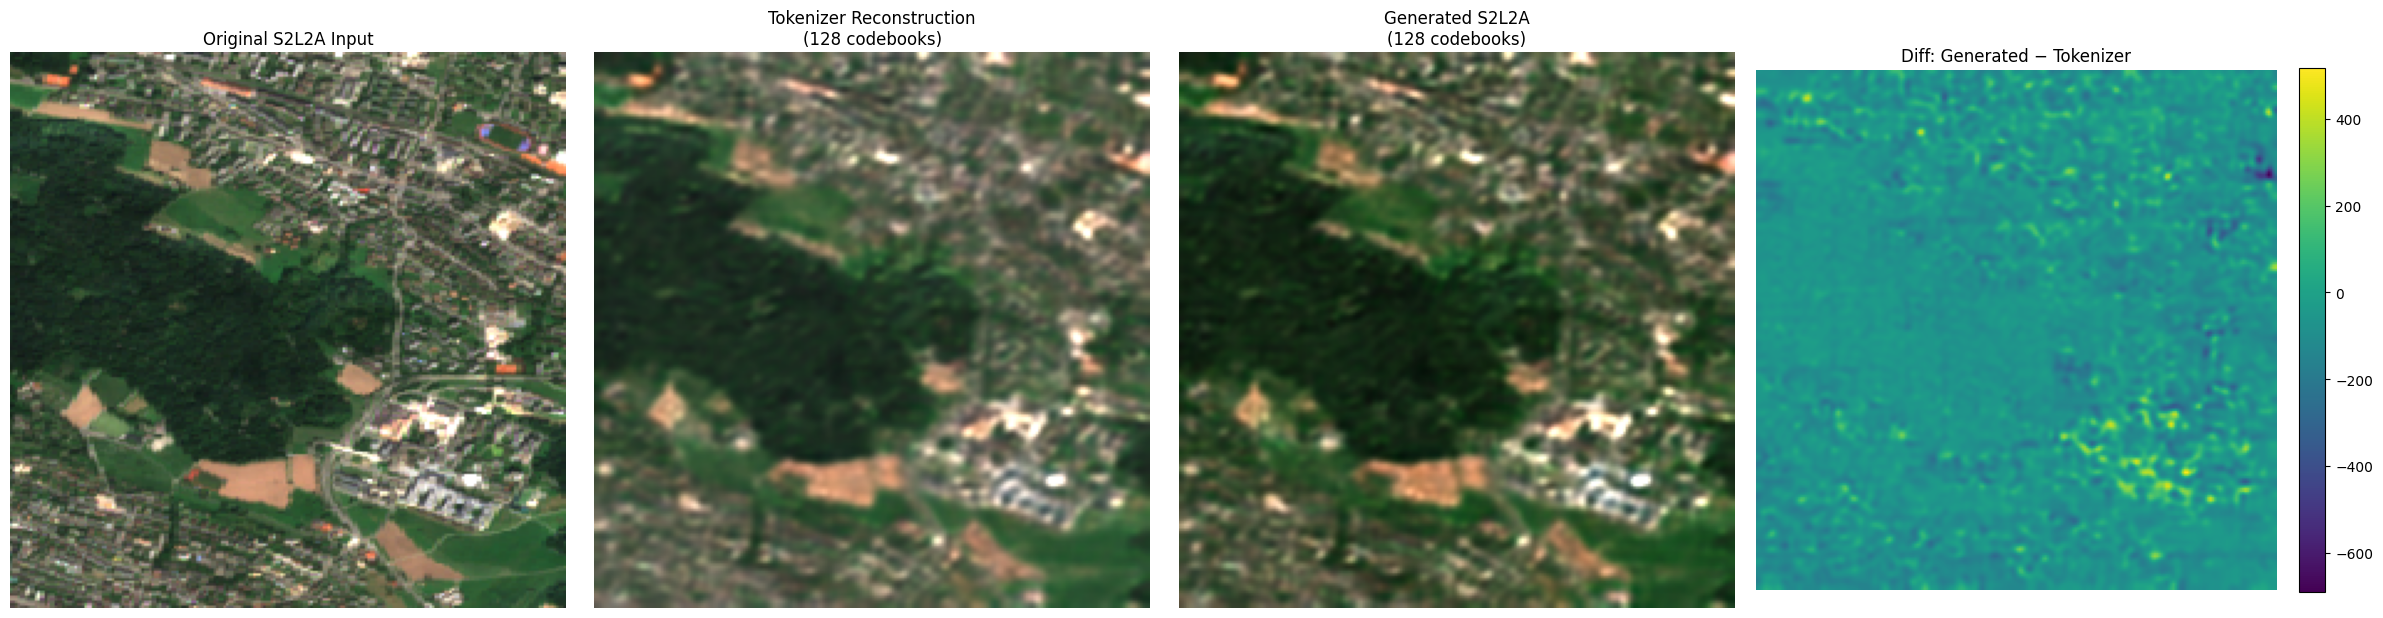

In [9]:
# Create plot
n_plots = 4  # Original + Reconstruction + Generated + Diff
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6))
axes = axes.flatten()

# Original
plot_modality(
    mod,
    data[modality],
    ax=axes[0],
    title='Original S2L2A Input'
)

# Tokenizer reconstruction
plot_modality(
    mod,
    reconstruction_unstd,
    ax=axes[1],
    title='Tokenizer Reconstruction\n(128 codebooks)'
)

# Generated
gen_mod, value = next(iter(generated.items()))
generated_unstd = value[0] * std[modality] + mean[modality]
generated_np = generated_unstd[0].cpu().numpy()

plot_modality(
    mod,
    generated_np,
    ax=axes[2],
    title='Generated S2L2A\n(128 codebooks)'
)

# Diff: Generated − Tokenizer
diff = generated_np - reconstruction_unstd.cpu().numpy()
im = axes[3].imshow(diff.squeeze()[2])
axes[3].set_title('Diff: Generated − Tokenizer')
axes[3].axis("off")

plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(
    'terramind_v1_5_generation_results.pdf',
    dpi=300,
    bbox_inches='tight'
)
plt.show()